# Examples for McKean-Vlasov control

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from main import McKeanVlasovSolver
from main import McKeanVlasovPlotter
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta

## Benedetto et al. (1998)

Consider $G(x) = \beta \frac{(x-\pi)^2}{2}$ and $W(x) = \lambda |x-\pi|^3$ over the interval $[0, 2\pi]$. 

The McKean-Vlasov equation with these functions is the homogeneous version of the transport equation in a thermal bath with temperature $\beta^{-1}$ that can be derived from inelastic collisons. 

In [3]:
G = lambda x: 300 * (x - np.pi)**2
W = lambda x: np.abs(x-np.pi)**3

alpha1 = lambda x: np.sin(x) / np.sqrt(4 * np.pi) 
alpha2 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
alpha3 = lambda x: np.sin(2*x) / np.sqrt(4 * np.pi) 
alpha4 = lambda x: np.cos(2*x) / np.sqrt(4 * np.pi) 

nabla_alpha1 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
nabla_alpha2 = lambda x: -np.sin(x) / np.sqrt(4 * np.pi) 
nabla_alpha3 = lambda x: 2 * np.cos(2*x) / np.sqrt(4 * np.pi) 
nabla_alpha4 = lambda x: -2 * np.sin(2*x) / np.sqrt(4 * np.pi) 

def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x):
    alpha_param1 = 4.0
    beta_param1 = 2.0
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)

    alpha_param2 = 2.0
    beta_param2 = 10.0
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)
    return 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1 + 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2

Solving the equation. 

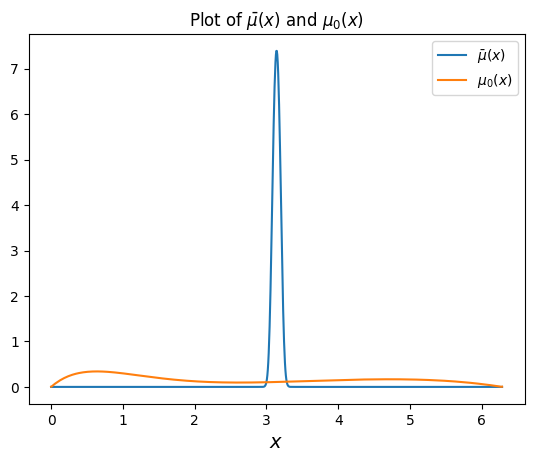

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.86.
MESSAGE - Nonlinear equation solved in 338.86.


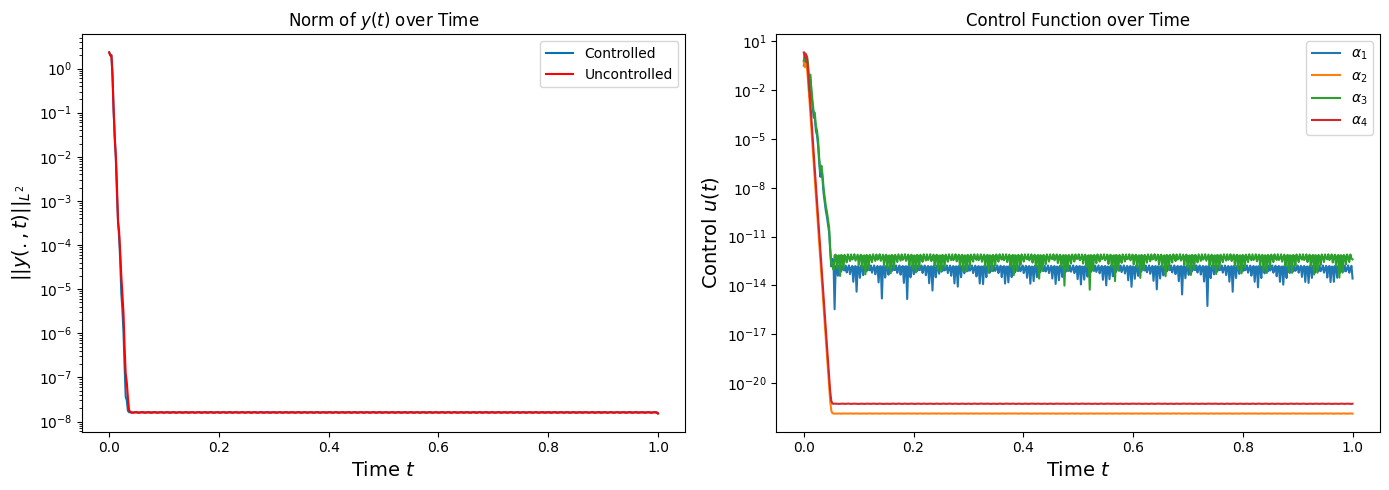

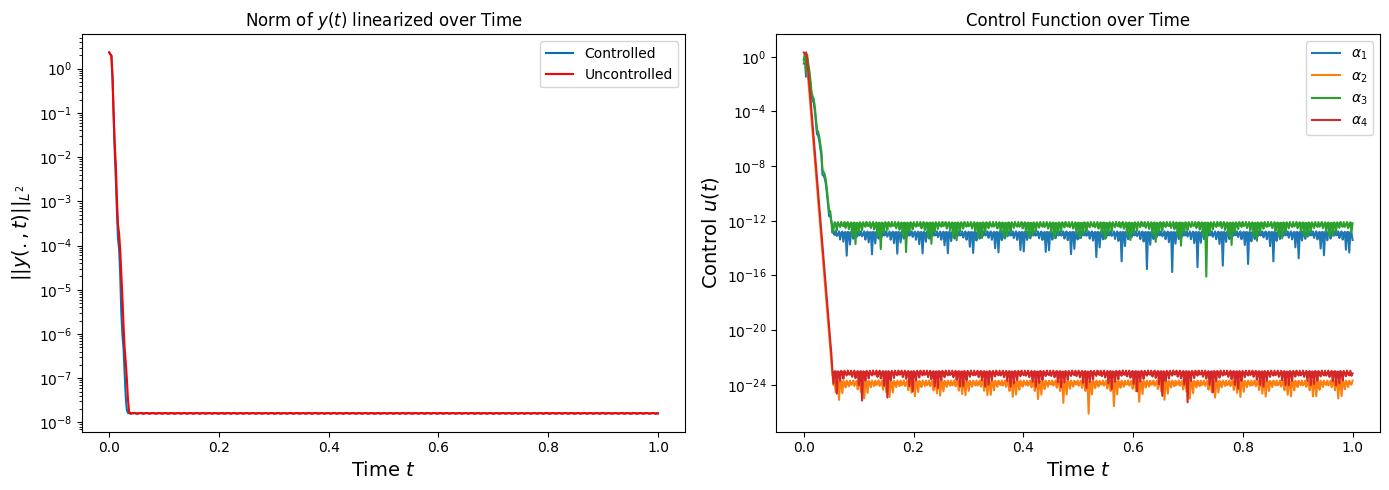

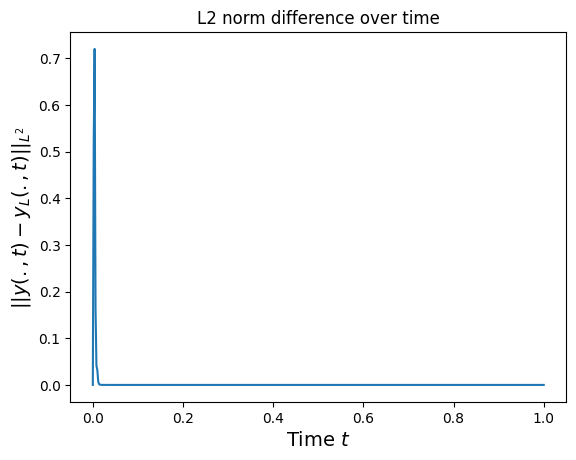

In [19]:
solver = McKeanVlasovSolver(L=100, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=1.0)
plotter.plot_control_and_norm_linear(t_max=1.0)
plotter.plot_y_diff_L2_norm(t_max=1.0)

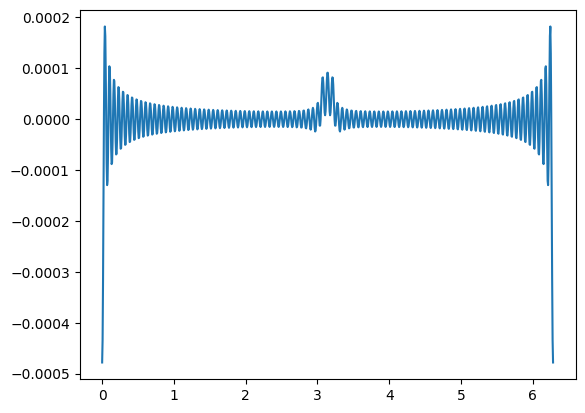

In [20]:
x = np.linspace(0, solver.d, 1000)
method2 = solver.compute_bar_mu_method2()
mu_bar = solver.reconstruction(solver.bar_mu_k, x)
mu_bar_method2 = solver.reconstruction(a=method2, x=x)

plt.figure()
plt.plot(x, mu_bar-mu_bar_method2)
plt.show()

Consider now a higher value of $beta$ (so a small temperature). 

In [21]:
G = lambda x: 300 * (x - np.pi)**2
W = lambda x: np.abs(x-np.pi)**3

alpha1 = lambda x: np.sin(x) / np.sqrt(4 * np.pi) 
alpha2 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
alpha3 = lambda x: np.sin(2*x) / np.sqrt(4 * np.pi) 
alpha4 = lambda x: np.cos(2*x) / np.sqrt(4 * np.pi) 

nabla_alpha1 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
nabla_alpha2 = lambda x: -np.sin(x) / np.sqrt(4 * np.pi) 
nabla_alpha3 = lambda x: 2 * np.cos(2*x) / np.sqrt(4 * np.pi) 
nabla_alpha4 = lambda x: -2 * np.sin(2*x) / np.sqrt(4 * np.pi) 

def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x):
    alpha_param1 = 4.0
    beta_param1 = 2.0
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)

    alpha_param2 = 2.0
    beta_param2 = 10.0
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)
    return 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1 + 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2

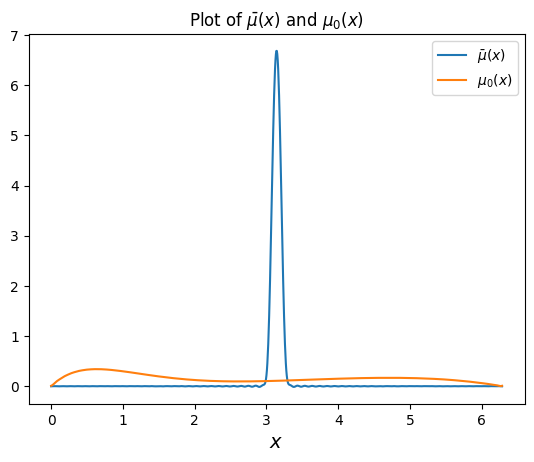

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.29.
MESSAGE - Nonlinear equation solved in 71.94.


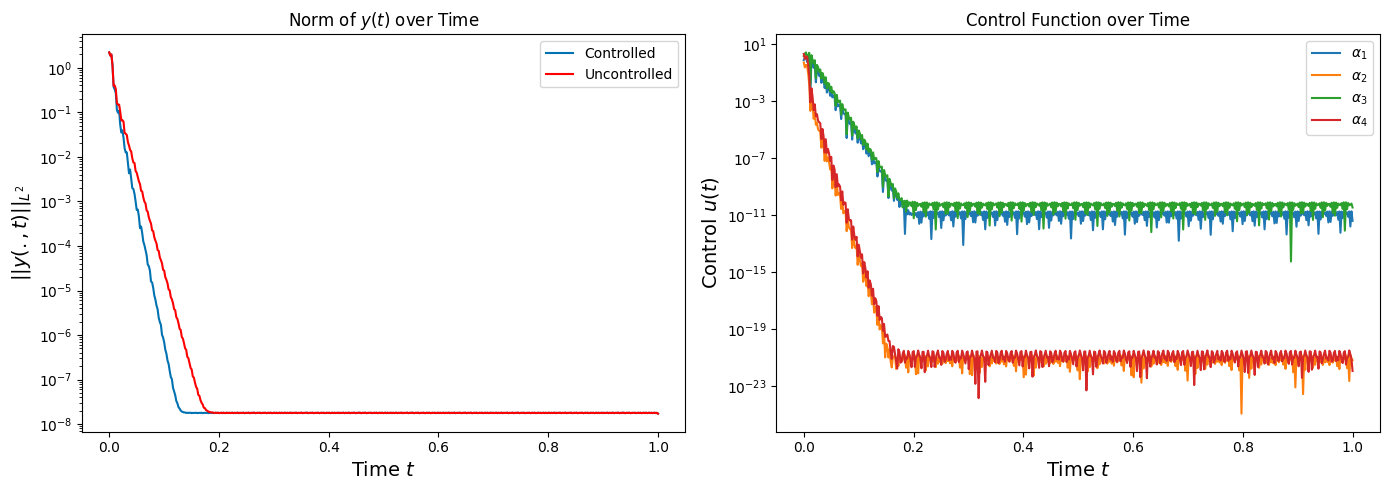

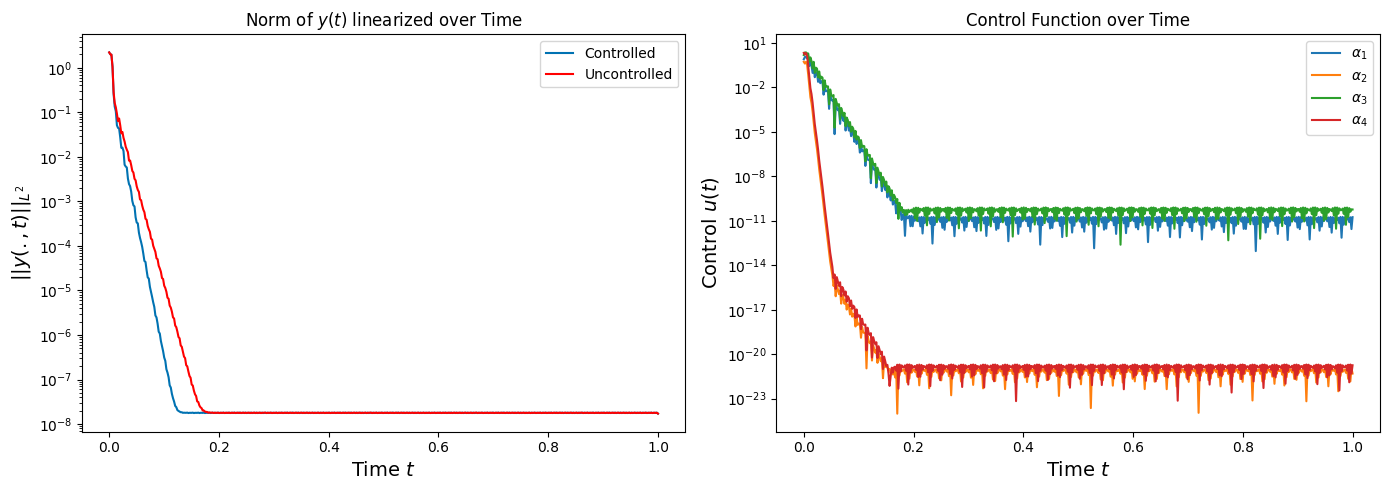

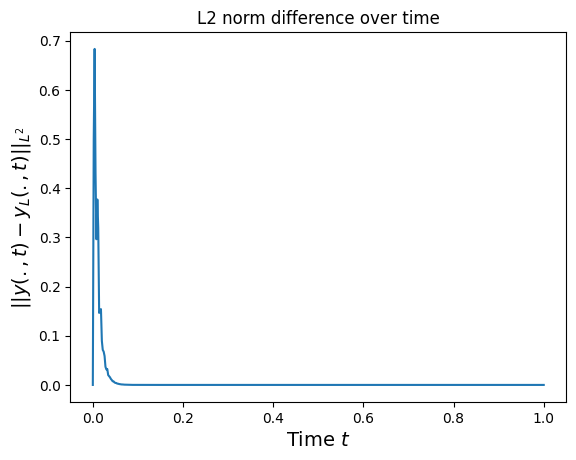

In [26]:
solver = McKeanVlasovSolver(L=60, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=1.0)
plotter.plot_control_and_norm_linear(t_max=1.0)
plotter.plot_y_diff_L2_norm(t_max=1.0)

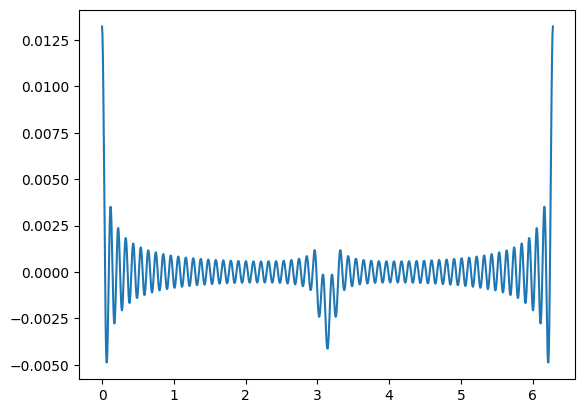

In [27]:
x = np.linspace(0, solver.d, 1000)
method2 = solver.compute_bar_mu_method2()
mu_bar = solver.reconstruction(solver.bar_mu_k, x)
mu_bar_method2 = solver.reconstruction(a=method2, x=x)

plt.figure()
plt.plot(x, mu_bar-mu_bar_method2)
plt.show()